In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_pkl(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)

processing_files = {
    "1 partition (16MB/s)":  "processing_metrics_partition_1part_rate16.pkl",
    "3 partitions (16MB/s)": "processing_metrics_partition_3part_rate16.pkl",
    "4 MB/s":  "processing_metrics_rate_4mbps.pkl",
    "16 MB/s": "processing_metrics_partition_1part_rate16.pkl",
    "30 MB/s": "processing_metrics_rate_30mbps.pkl",
    "60 MB/s": "processing_metrics_rate_60mbps.pkl",
}

producer_files = {
    "1 partition (16MB/s)":  "producer_metrics_partition_1part_rate16.pkl",
    "3 partitions (16MB/s)": "producer_metrics_partition_3part_rate16.pkl",
    "4 MB/s":  "producer_metrics_rate_4mbps.pkl",
    "16 MB/s": "producer_metrics_partition_1part_rate16.pkl",
    "30 MB/s": "producer_metrics_rate_30mbps.pkl",
    "60 MB/s": "producer_metrics_rate_60mbps.pkl",
}

processing_data = {label: load_pkl(fname) for label, fname in processing_files.items()}
producer_data = {label: load_pkl(fname) for label, fname in producer_files.items()}

print("Trials carregados:", list(processing_data.keys()))

Trials carregados: ['1 partition (16MB/s)', '3 partitions (16MB/s)', '4 MB/s', '16 MB/s', '30 MB/s', '60 MB/s']


In [2]:
def snapshots_to_df(metrics):
    df = pd.DataFrame(metrics["snapshots"])
    if df.empty:
        return df
    df["elapsed_min"] = df["elapsed_s"] / 60
    # versões diferentes do código usaram "pending_futures" ou "queue_depth" —
    # normaliza pra um nome único
    if "pending_futures" not in df.columns and "queue_depth" in df.columns:
        df["pending_futures"] = df["queue_depth"]
    return df

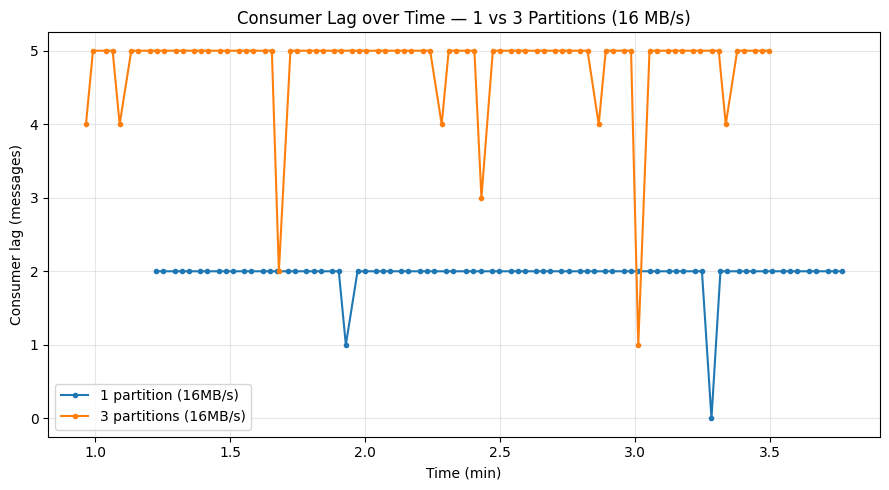

In [4]:
partition_labels = ["1 partition (16MB/s)", "3 partitions (16MB/s)"]

fig, ax = plt.subplots(figsize=(9, 5))
for label in partition_labels:
    df = snapshots_to_df(processing_data[label])
    ax.plot(df["elapsed_min"], df["consumer_lag"], marker='o', markersize=3, label=label)

ax.set_xlabel("Time (min)")
ax.set_ylabel("Consumer lag (messages)")
ax.set_title("Consumer Lag over Time — 1 vs 3 Partitions (16 MB/s)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lag_partitioning_comparison.png", dpi=150)
plt.show()

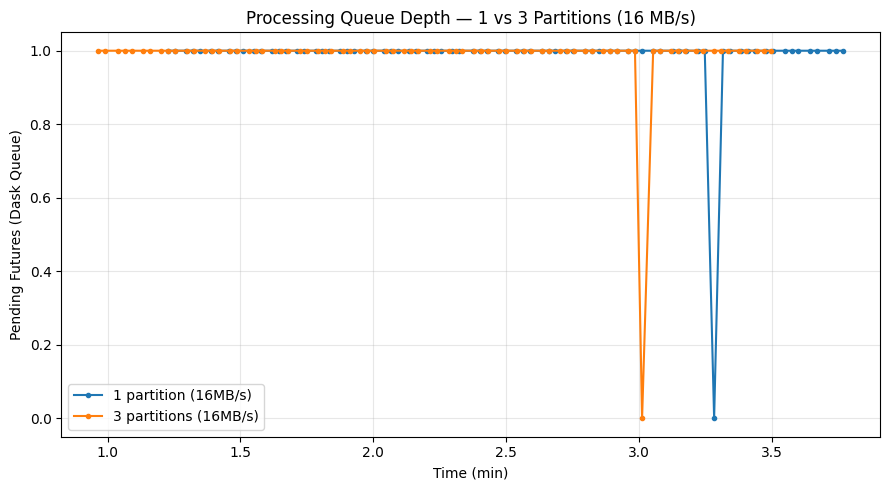

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for label in partition_labels:
    df = snapshots_to_df(processing_data[label])
    ax.plot(df["elapsed_min"], df["pending_futures"], marker='o', markersize=3, label=label)

ax.set_xlabel("Time (min)")
ax.set_ylabel("Pending Futures (Dask Queue)")
ax.set_title("Processing Queue Depth — 1 vs 3 Partitions (16 MB/s)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("queue_partitioning_comparison.png", dpi=150)
plt.show()

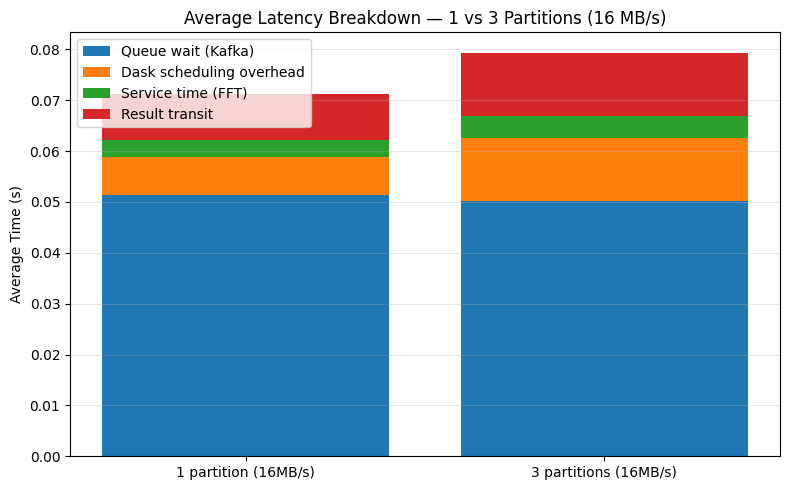

In [6]:
latency_components = ["queue_wait", "dask_scheduling_overhead", "service_time", "result_transit"]
component_labels_pt = {
    "queue_wait": "Queue wait (Kafka)",
    "dask_scheduling_overhead": "Dask scheduling overhead",
    "service_time": "Service time (FFT)",
    "result_transit": "Result transit",
}

fig, ax = plt.subplots(figsize=(8, 5))
bottoms = np.zeros(len(partition_labels))
x_pos = np.arange(len(partition_labels))

for comp in latency_components:
    values = [processing_data[label][comp]["mean_s"] for label in partition_labels]
    ax.bar(x_pos, values, bottom=bottoms, label=component_labels_pt[comp])
    bottoms += np.array(values)

ax.set_xticks(x_pos)
ax.set_xticklabels(partition_labels)
ax.set_ylabel("Average Time (s)")
ax.set_title("Average Latency Breakdown — 1 vs 3 Partitions (16 MB/s)")
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("latency_breakdown_partitioning.png", dpi=150)
plt.show()

In both scenarios, consumer lag remained strictly bounded and stable (fluctuating between 0–2 messages for 1 partition, and 1–5 messages for 3 partitions), indicating that the processing pipeline successfully sustained real-time ingestion without saturation.

The characteristic saw-tooth pattern observed in the telemetry reflects batch consumption mechanisms triggered by the fetch.min.bytes=1048576 parameter, where messages accumulate until the 1MB threshold is met and are then drained instantaneously. 

The higher baseline lag in the 3-partition run is a mechanical artifact of aggregating individual residual partition buffering across multiple channels rather than a performance regression. 

The Dask pending futures queue remained consistently at a depth of 1 confirming that tasks are dispatched and executed on worker nodes immediately upon arrival without accumulating a computational backlog, a result highly consistent with the low average worker service time (~3–4 ms).

End-to-end latency analysis reveals that network queuing delays remained virtually unchanged between the two runs (~0.051s vs ~0.050s). However, the 3-partition setup introduced a noticeable increase in Dask scheduling overhead. Because a single-threaded Python orchestrator handles the ingestion loop, consuming from interleaved partitions increased coordinate matching and task submission complexity without introducing any parallel performance gains.

Increasing the number of Kafka partitions adds architectural complexity and scheduling overhead without improving throughput. This demonstrates that the pipeline's primary constraint does not lie within the Kafka ingestion stage, but rather inside the single-threaded Python orchestration loop and Dask task-dispatch layer. 

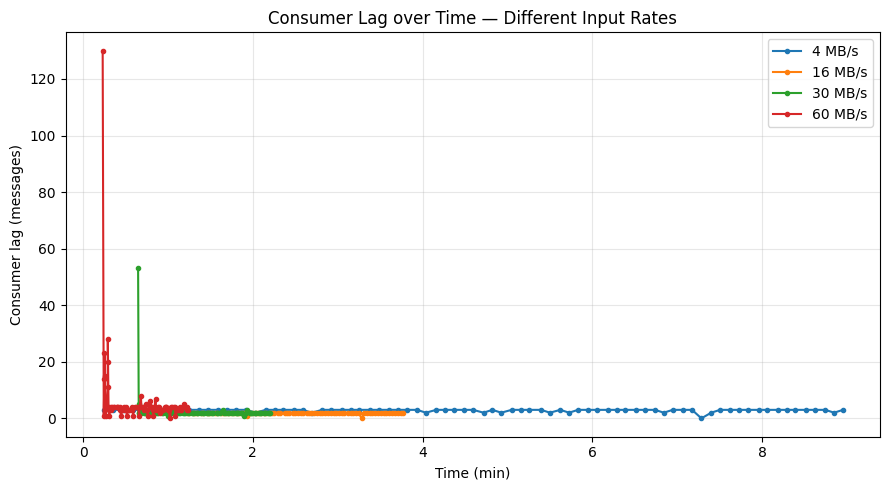

In [7]:
rate_labels = ["4 MB/s", "16 MB/s", "30 MB/s", "60 MB/s"]

fig, ax = plt.subplots(figsize=(9, 5))
for label in rate_labels:
    df = snapshots_to_df(processing_data[label])
    ax.plot(df["elapsed_min"], df["consumer_lag"], marker='o', markersize=3, label=label)

ax.set_xlabel("Time (min)")
ax.set_ylabel("Consumer lag (messages)")
ax.set_title("Consumer Lag over Time — Different Input Rates")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lag_rate_comparison.png", dpi=150)
plt.show()

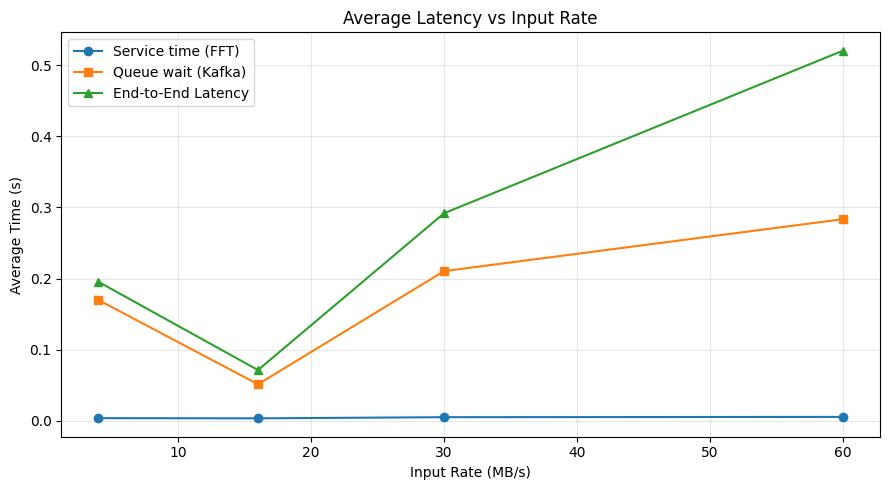

In [9]:
rate_values_mbps = [4, 16, 30, 60]

service_means = [processing_data[l]["service_time"]["mean_s"] for l in rate_labels]
queue_means   = [processing_data[l]["queue_wait"]["mean_s"] for l in rate_labels]
e2e_means     = [processing_data[l]["end_to_end_latency"]["mean_s"] for l in rate_labels]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rate_values_mbps, service_means, marker='o', label="Service time (FFT)")
ax.plot(rate_values_mbps, queue_means, marker='s', label="Queue wait (Kafka)")
ax.plot(rate_values_mbps, e2e_means, marker='^', label="End-to-End Latency")
ax.set_xlabel("Input Rate (MB/s)")
ax.set_ylabel("Average Time (s)")
ax.set_title("Average Latency vs Input Rate")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("latency_vs_rate.png", dpi=150)
plt.show()

In [11]:
summary_rows = []
for label, pm in processing_data.items():
    prod = producer_data[label]
    summary_rows.append({
        "Trial": label,
        "Processed chunks": pm.get("total_chunks_processed"),
        "Duration (s)": round(pm.get("wall_clock_duration_s", 0), 1),
        "Target rate (MB/s)": prod.get("target_rate_mb_s"),
        "Achieved rate (MB/s)": round(prod["achieved_avg_rate_mb_s"], 2) if prod.get("achieved_avg_rate_mb_s") else None,
        "Average E2E latency (s)": round(pm["end_to_end_latency"]["mean_s"], 4),
        "Average service time (s)": round(pm["service_time"]["mean_s"], 4),
        "Average queue wait (s)": round(pm["queue_wait"]["mean_s"], 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Trial,Processed chunks,Duration (s),Target rate (MB/s),Achieved rate (MB/s),Average E2E latency (s),Average service time (s),Average queue wait (s)
0,1 partition (16MB/s),3968,227.1,16.0,12.67,0.0713,0.0034,0.0513
1,3 partitions (16MB/s),3968,210.8,16.0,12.72,0.0794,0.0042,0.0502
2,4 MB/s,3968,612.2,4.0,3.73,0.1953,0.0037,0.1697
3,16 MB/s,3968,227.1,16.0,12.67,0.0713,0.0034,0.0513
4,30 MB/s,3968,154.3,30.0,19.47,0.2918,0.0050,0.2104
5,60 MB/s,3968,79.7,60.0,29.51,0.5203,0.0054,0.2834


A systematic evaluation of the pipeline's efficiency under scaling target input rates (4.0, 16.0, 30.0, and 60.0 MB/s) revealed a monotonic decay in relative efficiency. This behavior is driven by an architectural bottleneck within the ingestion layer of producer.py. While the internal throttling mechanism regulates the network streaming duration ($T_{\text{stream},i}$), the S3 data retrieval phase ($T_{\text{download},i}$) operates sequentially outside this closed-loop control.

Formally, the total duration for processing each data file $i$ is defined as:$$T_i = T_{\text{download},i} + T_{\text{stream},i} \quad \text{where} \quad T_{\text{stream},i} \approx \frac{\text{bytes}_i}{\text{target-rate}}$$As the target input rate scales toward infinity ($\text{target-rate} \to \infty$), the streaming duration asymptotically approaches zero ($T_{\text{stream},i} \to 0$), while the sequential download overhead remains fixed by the external network infrastructure constraints. Consequently, the overall system duration hits a strict physical floor.

Telemetry logs extracted from the producer_metrics_*.pkl files confirm that due to this serialization of S3 downloads and Kafka streaming, the system saturates at an upper bound of approximately ~30 MB/s, even when a target rate of 60 MB/s is requested. As the target rate scales up, the download duration represents a progressively dominant fraction of the total execution wall-clock time.

Telemetry regarding processing delays shows that the Dask worker service time required for the Fast Fourier Transform (FFT) computations remained flat and invariant (~3–5 ms) across all stress-testing rates. This decouples the cluster computational capacity from the performance degradation, confirming that the Dask execution layer is not the pipeline bottleneck. Instead, end-to-end (E2E) latency scaling is dominated by queue wait times within the orchestration loop.

However, a localized non-monotonic anomaly was observed: the E2E latency at 16.0 MB/s was significantly lower than at a relaxed rate of 4.0 MB/s (0.071s vs. 0.195s, respectively). This behavior is an direct consequence of the Kafka consumer configuration parameter fetch.min.bytes=1048576. At ultra-low data ingestion rates (4.0 MB/s), individual messages undergo extended buffer accumulation delays at the broker layer while waiting to fulfill the 1MB minimum chunk threshold. Conversely, moderate operational rates (16.0 MB/s) saturate this byte threshold rapidly, optimizing batching efficiency and driving down the mean latency per message. This highlights a critical operational trade-off inherent to Kafka's batch processing configuration that must be balanced against high-throughput requirements.